<a href="https://colab.research.google.com/github/Rak16-nub04/Machine-Learning/blob/main/Porosity(Mean).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


file_path = '/content/AlSi10Mg PSP feature table.xlsx'
df = pd.read_excel(file_path, sheet_name='PSP linkage')


selected_columns = [
    'Power P (W)', 'Speed v (mm/s)', 'Layer Thickness t (mm)', 'Hatch Spacing h (mm)',
    'Porosity (Mean Value)',
    'Porosity (Standard Deviation)'
]




processed_df = df.iloc[:, [2, 3, 4, 5, 32, 33]].copy()


processed_df.columns = [
    'Power P (W)', 'Speed v (mm/s)', 'Layer Thickness t (mm)', 'Hatch Spacing h (mm)',
    'Porosity (Mean Value)',
    'Porosity (Standard Deviation)',

]


processed_df = processed_df.dropna()


print(processed_df.head())


processed_df.to_csv('processed_data_porsity.csv', index=False)

   Power P (W)  Speed v (mm/s)  Layer Thickness t (mm)  Hatch Spacing h (mm)  \
2  Power P (W)  Speed v (mm/s)  Layer Thickness t (mm)  Hatch Spacing h (mm)   
3           60             250                    0.06                   0.1   
4          160             250                    0.06                   0.1   
5          160             800                    0.06                   0.1   
6          160            1350                    0.06                   0.1   

  Porosity (Mean Value) Porosity (Standard Deviation)  
2           Mean Value             Standard Deviation  
3              0.044643                      0.020316  
4              0.270462                      0.019378  
5              0.260757                      0.034028  
6                0.0694                      0.005576  


In [ ]:
import pandas as pd


df = pd.read_csv('processed_data_porsity.csv')


df = df.drop(index=0).reset_index(drop=True)


df.to_csv('processed_data_porsity_remake.csv', index=False)

print("2nd row deleted and rows shifted up successfully!")
print("processed_data_porsity_remake.csv'")

2nd row deleted and rows shifted up successfully!
processed_data_porsity_remake.csv'


###Skip this one


Gaussian Mixture Model Analysis:

Cluster 0 (n=9):
Mean Porosity: 0.2028
Std Porosity: 0.0177
Feature means:
Power P (W)               148.888889
Speed v (mm/s)            544.444444
Layer Thickness t (mm)      0.060000
Hatch Spacing h (mm)        0.100000
dtype: float64

Cluster 1 (n=22):
Mean Porosity: 3.5014
Std Porosity: 0.1068
Feature means:
Power P (W)               300.909091
Speed v (mm/s)            825.000000
Layer Thickness t (mm)      0.060000
Hatch Spacing h (mm)        0.150000
dtype: float64

Cluster 2 (n=16):
Mean Porosity: 0.6011
Std Porosity: 0.0330
Feature means:
Power P (W)                363.125
Speed v (mm/s)            1415.625
Layer Thickness t (mm)       0.060
Hatch Spacing h (mm)         0.100
dtype: float64

Regression Models:

Linear Regression - Mean Porosity:

Mean Porosity Regression Results:
MSE: 8.0649
MAE: 2.1210
R2 Score: 0.3114


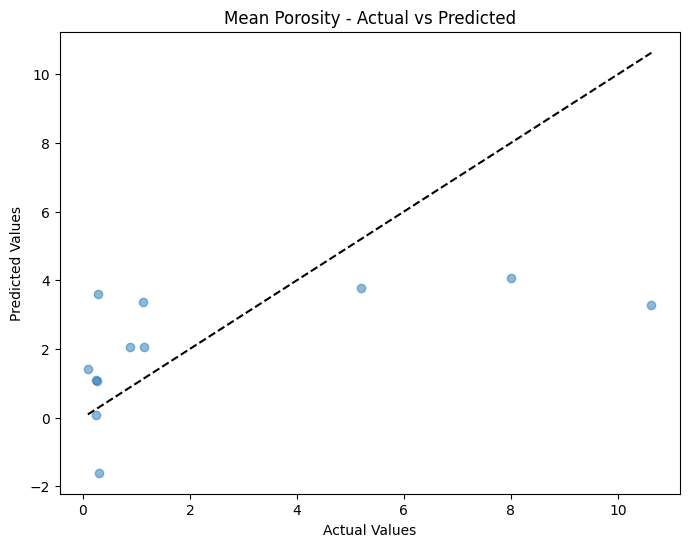


Linear Regression - Std Porosity:

Std Porosity Regression Results:
MSE: 0.0057
MAE: 0.0559
R2 Score: 0.3129


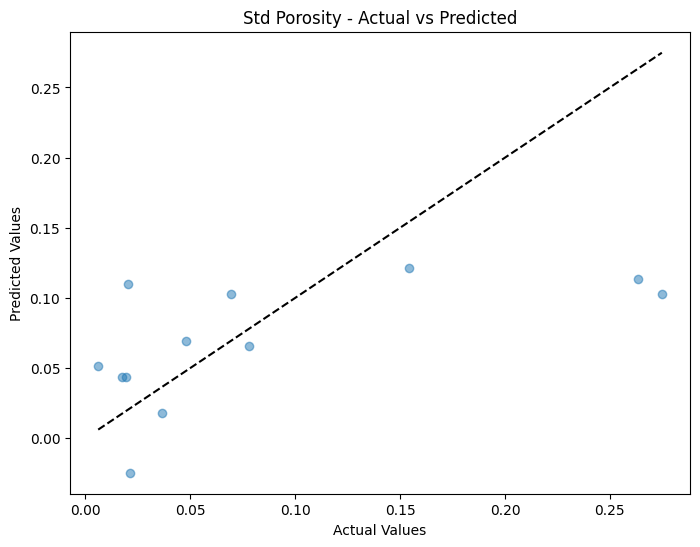


Neural Network Models:

Neural Network - Mean Porosity:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Neural Network - Std Porosity:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

Mean Porosity Neural Network Results:
MSE: 4.4629
MAE: 1.2898
R2 Score: 0.6189


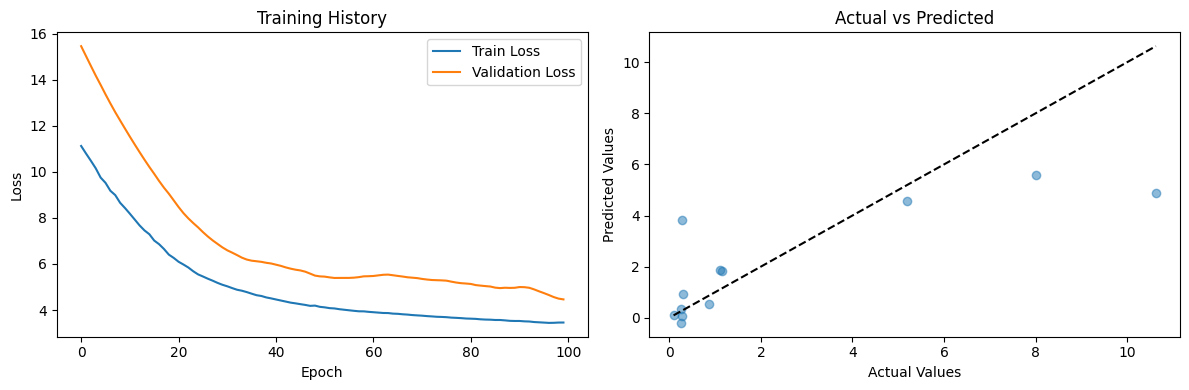

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Std Porosity Neural Network Results:
MSE: 0.0055
MAE: 0.0534
R2 Score: 0.3394


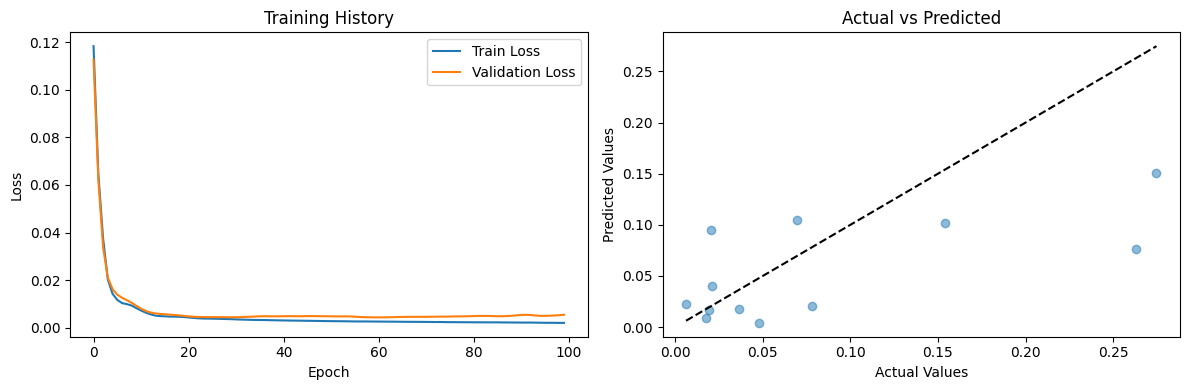

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


data = pd.read_csv('processed_data_porsity_remake.csv')

X = data[['Power P (W)', 'Speed v (mm/s)', 'Layer Thickness t (mm)', 'Hatch Spacing h (mm)']]
y_mean = data['Porosity (Mean Value)']
y_std = data['Porosity (Standard Deviation)']

# Split data into training and testing sets
X_train, X_test, y_mean_train, y_mean_test, y_std_train, y_std_test = train_test_split(
    X, y_mean, y_std, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Gaussian Mixture Model (GMM) - Clustering
print("\nGaussian Mixture Model Analysis:")
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_train_scaled)

# Predict clusters
clusters = gmm.predict(X_train_scaled)

# Analyze porosity by cluster
for cluster in np.unique(clusters):
    cluster_mask = (clusters == cluster)
    print(f"\nCluster {cluster} (n={cluster_mask.sum()}):")
    print(f"Mean Porosity: {y_mean_train[cluster_mask].mean():.4f}")
    print(f"Std Porosity: {y_std_train[cluster_mask].mean():.4f}")
    print("Feature means:")
    print(X_train.iloc[cluster_mask].mean())

# 2. Regression Models
print("\nRegression Models:")

# Function to evaluate regression models
def evaluate_regression(model, X_train, X_test, y_train, y_test, target_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{target_name} Regression Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{target_name} - Actual vs Predicted')
    plt.show()

    return model

# Mean Porosity Regression
print("\nLinear Regression - Mean Porosity:")
lr_mean = evaluate_regression(LinearRegression(),
                             X_train_scaled, X_test_scaled,
                             y_mean_train, y_mean_test,
                             "Mean Porosity")

# Std Porosity Regression
print("\nLinear Regression - Std Porosity:")
lr_std = evaluate_regression(LinearRegression(),
                            X_train_scaled, X_test_scaled,
                            y_std_train, y_std_test,
                            "Std Porosity")

# 3. Neural Network Models
print("\nNeural Network Models:")

def build_nn(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

# Mean Porosity NN
print("\nNeural Network - Mean Porosity:")
nn_mean = build_nn(X_train_scaled.shape[1])
history_mean = nn_mean.fit(
    X_train_scaled, y_mean_train,
    validation_data=(X_test_scaled, y_mean_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

# Std Porosity NN
print("\nNeural Network - Std Porosity:")
nn_std = build_nn(X_train_scaled.shape[1])
history_std = nn_std.fit(
    X_train_scaled, y_std_train,
    validation_data=(X_test_scaled, y_std_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

# Evaluate NN models
def evaluate_nn(model, history, X_test, y_test, target_name):
    y_pred = model.predict(X_test).flatten()

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{target_name} Neural Network Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training History')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted')

    plt.tight_layout()
    plt.show()

# Evaluate Mean Porosity NN
evaluate_nn(nn_mean, history_mean, X_test_scaled, y_mean_test, "Mean Porosity")

# Evaluate Std Porosity NN
evaluate_nn(nn_std, history_std, X_test_scaled, y_std_test, "Std Porosity")

###Neural Network R2 = 0.826

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Model Performance Comparison:
Linear Regression: R² = 0.311, RMSE = 2.840
Random Forest: R² = 0.178, RMSE = 3.103
XGBoost: R² = 0.027, RMSE = 3.375
SVR: R² = 0.156, RMSE = 3.143
Neural Network: R² = 0.826, RMSE = 1.427


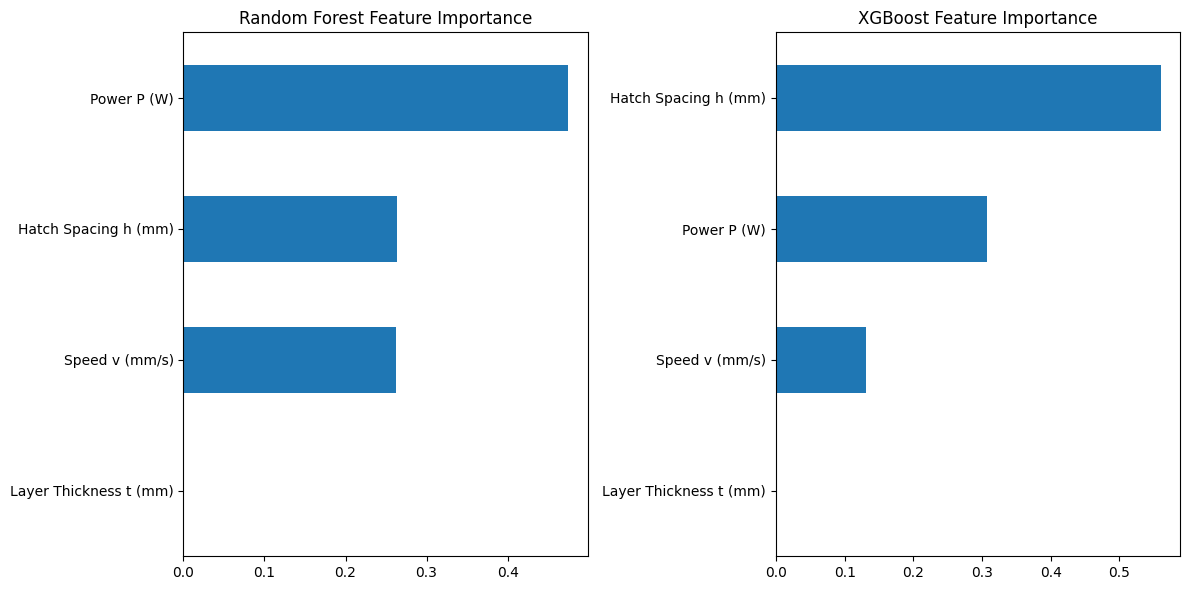

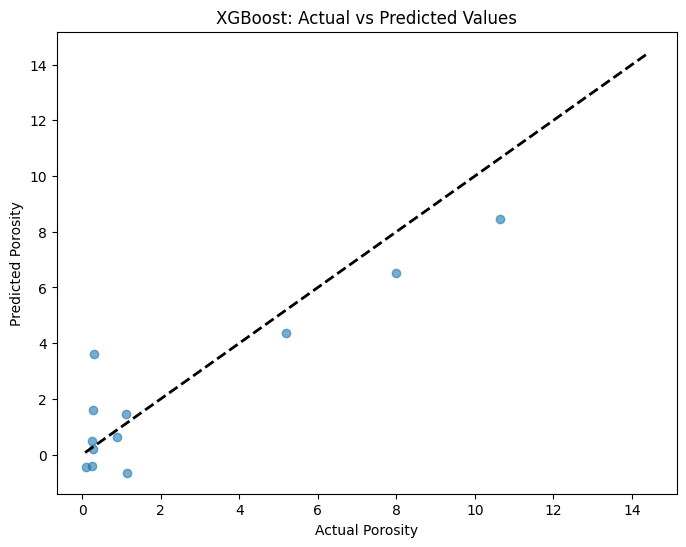

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt


df = pd.read_csv("processed_data_porsity_remake.csv")
X = df[["Power P (W)", "Speed v (mm/s)", "Layer Thickness t (mm)", "Hatch Spacing h (mm)"]]
y = df["Porosity (Mean Value)"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


results = {}

# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results["Linear Regression"] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
results["Random Forest"] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

# XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
results["XGBoost"] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

# Support Vector Regression
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
results["SVR"] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

# Neural Network
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(hidden_layer_sizes=(50, 20), activation='relu',
                 solver='adam', max_iter=1000, random_state=42)
nn.fit(X_train_scaled, y_train)
y_pred = nn.predict(X_test_scaled)
results["Neural Network"] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}


print("Model Performance Comparison:")
for model, metrics in results.items():
    print(f"{model}: R² = {metrics['R2']:.3f}, RMSE = {metrics['RMSE']:.3f}")

# Feature Importance Visualization (for tree-based models)
plt.figure(figsize=(12, 6))
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)

plt.subplot(1, 2, 1)
rf_importance.sort_values().plot(kind='barh', title='Random Forest Feature Importance')
plt.subplot(1, 2, 2)
xgb_importance.sort_values().plot(kind='barh', title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Porosity')
plt.ylabel('Predicted Porosity')
plt.title('XGBoost: Actual vs Predicted Values')
plt.show()

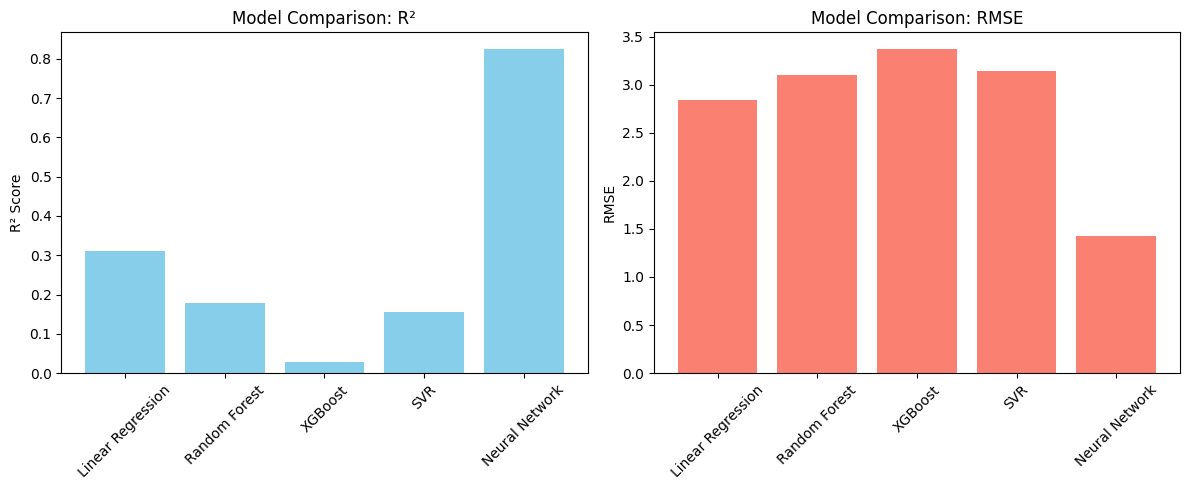

In [ ]:
models = list(results.keys())
r2_values = [results[model]['R2'] for model in models]
rmse_values = [results[model]['RMSE'] for model in models]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(models, r2_values, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('R² Score')
plt.title('Model Comparison: R²')

plt.subplot(1, 2, 2)
plt.bar(models, rmse_values, color='salmon')
plt.xticks(rotation=45)
plt.ylabel('RMSE')
plt.title('Model Comparison: RMSE')
plt.tight_layout()
plt.show()

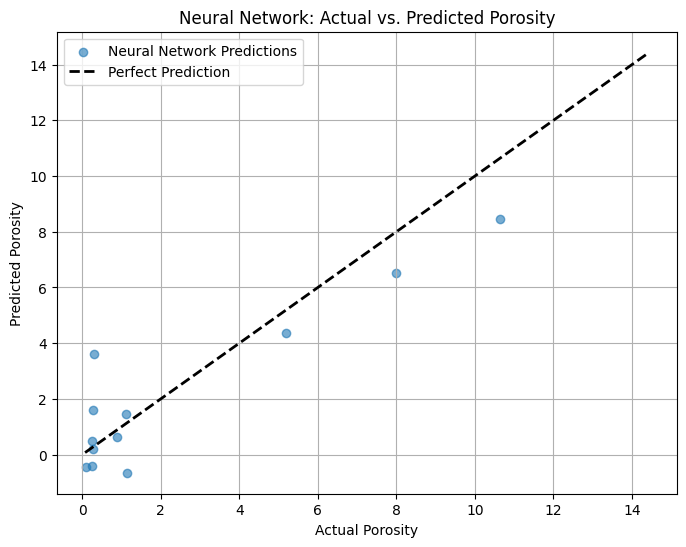

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, nn.predict(X_test_scaled), alpha=0.6, label='Neural Network Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Porosity')
plt.ylabel('Predicted Porosity')
plt.title('Neural Network: Actual vs. Predicted Porosity')
plt.legend()
plt.grid(True)
plt.show()

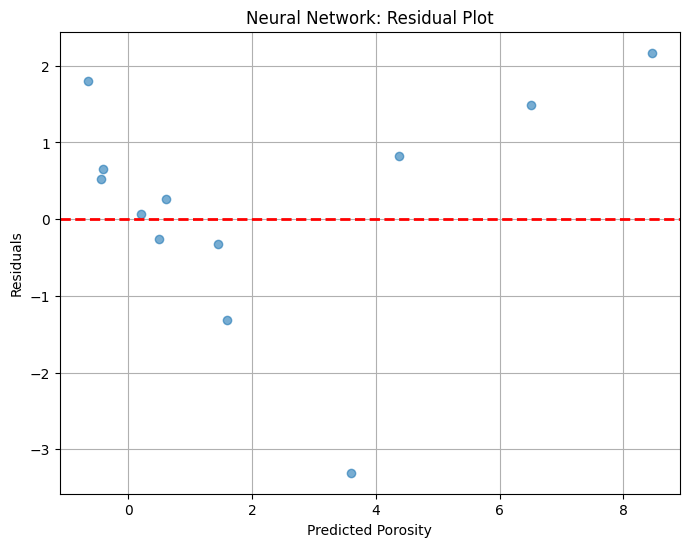

In [ ]:
residuals = y_test - nn.predict(X_test_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(nn.predict(X_test_scaled), residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Porosity')
plt.ylabel('Residuals')
plt.title('Neural Network: Residual Plot')
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perce

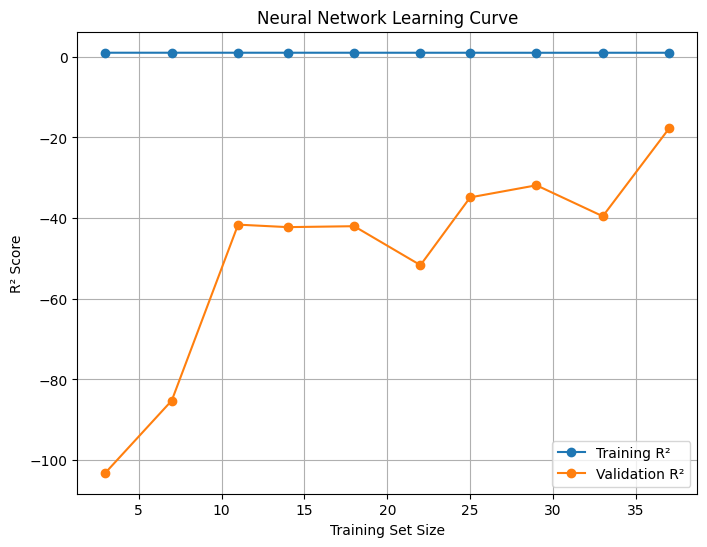

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    nn, X_train_scaled, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training R²')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation R²')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Neural Network Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


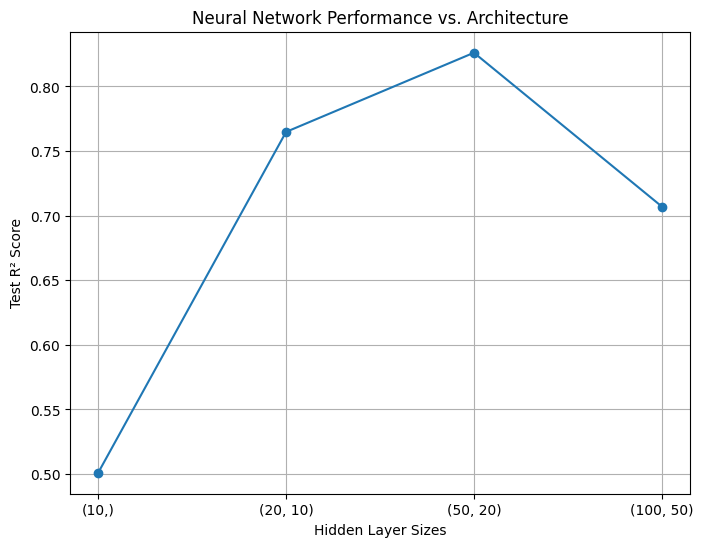

In [ ]:
layer_sizes = [(10,), (20, 10), (50, 20), (100, 50)]
r2_scores = []
for size in layer_sizes:
    nn = MLPRegressor(hidden_layer_sizes=size, max_iter=1000, random_state=42)
    nn.fit(X_train_scaled, y_train)
    r2_scores.append(r2_score(y_test, nn.predict(X_test_scaled)))
plt.figure(figsize=(8, 6))
plt.plot(range(len(layer_sizes)), r2_scores, 'o-')
plt.xticks(range(len(layer_sizes)), [str(size) for size in layer_sizes])
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Test R² Score')
plt.title('Neural Network Performance vs. Architecture')
plt.grid(True)
plt.show()

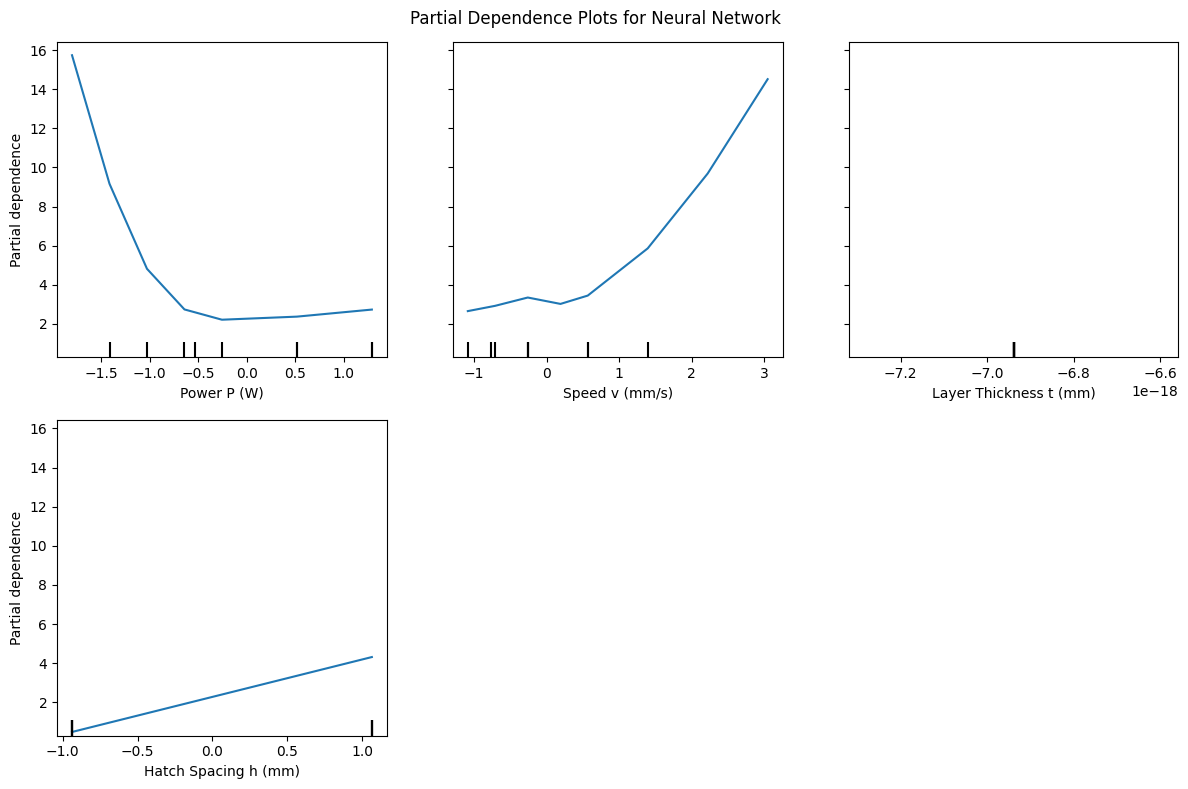

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
features = [0, 1, 2, 3]  # Indices of features in X
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    nn, X_train_scaled, features, feature_names=X.columns, ax=ax
)
plt.suptitle('Partial Dependence Plots for Neural Network')
plt.tight_layout()
plt.show()

###NN


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network Performance:
R² = 0.826
RMSE = 1.427


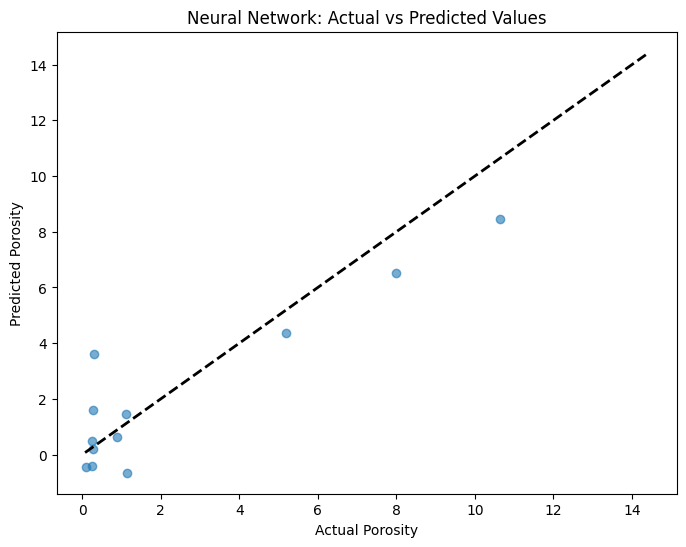

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("processed_data_porsity_remake.csv")
X = df[["Power P (W)", "Speed v (mm/s)", "Layer Thickness t (mm)", "Hatch Spacing h (mm)"]]
y = df["Porosity (Mean Value)"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Neural Network model
nn = MLPRegressor(hidden_layer_sizes=(50, 20), activation='relu',
                 solver='adam', max_iter=1000, random_state=42)
nn.fit(X_train_scaled, y_train)

# Predictions
y_pred = nn.predict(X_test_scaled)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Neural Network Performance:")
print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Porosity')
plt.ylabel('Predicted Porosity')
plt.title('Neural Network: Actual vs Predicted Values')
plt.show()

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100), (200, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': loguniform(1e-5, 1e-1),
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [2000, 5000]
}

nn = MLPRegressor(random_state=42)
search = RandomizedSearchCV(nn, param_dist, n_iter=50, cv=5,
                           scoring='r2', n_jobs=-1, verbose=1)
search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=MLPRegressor(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78f318ab8dd0>,
                                        'hidden_layer_sizes': [(50, 50),
                                                               (100, 50),
                                                               (100, 100),
                                                               (200, 100)],
                                        'learning_rate': ['constant',
                                                          'adaptive'],
                                        'max_iter': [2000, 5000],
                                        'solver': ['adam', 'lbfgs']},
                   scoring='r2', verbose=1)

In [ ]:
from scipy.stats import uniform

class LogUniform:
    def __init__(self, low, high):
        self.low = np.log(low)
        self.high = np.log(high)
    def rvs(self, size=None, random_state=None):
        return np.exp(uniform(self.low, self.high - self.low).rvs(size=size, random_state=random_state))

param_dist = {
    'alpha': LogUniform(1e-5, 1e-1),

}

In [ ]:
from scipy.stats import reciprocal

param_dist = {
    'alpha': reciprocal(1e-5, 1e-1),

}

In [ ]:

!pip install --upgrade scipy

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100), (200, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': loguniform(1e-5, 1e-1),
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [2000, 5000]
}

nn = MLPRegressor(random_state=42)
search = RandomizedSearchCV(nn, param_dist, n_iter=50, cv=5,
                           scoring='r2', n_jobs=-1, verbose=1)
search.fit(X_train_scaled, y_train)

print(f"Best R²: {search.best_score_:.3f}")
print(f"Best Params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best R²: -2.778
Best Params: {'activation': 'relu', 'alpha': np.float64(1.019548661517816e-05), 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'max_iter': 5000, 'solver': 'lbfgs'}


In [ ]:
# Check train/test split sizes
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Verify scaling (mean should be ~0, std ~1 for training set)
print("Train mean:", np.mean(X_train_scaled, axis=0))
print("Train std:", np.std(X_train_scaled, axis=0))

Train size: 47, Test size: 12
Train mean: [-1.06297949e-16 -1.41730599e-17 -6.93889390e-18  1.41730599e-16]
Train std: [1. 1. 0. 1.]


In [ ]:
nn = MLPRegressor(
    hidden_layer_sizes=(20, 10),  # Fewer layers/neurons
    activation='relu',
    solver='adam',
    alpha=0.001,  # Moderate regularization
    max_iter=1000,
    random_state=42
)
nn.fit(X_train_scaled, y_train)
y_pred = nn.predict(X_test_scaled)
print(f"R²: {r2_score(y_test, y_pred):.3f}")

R²: 0.763


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


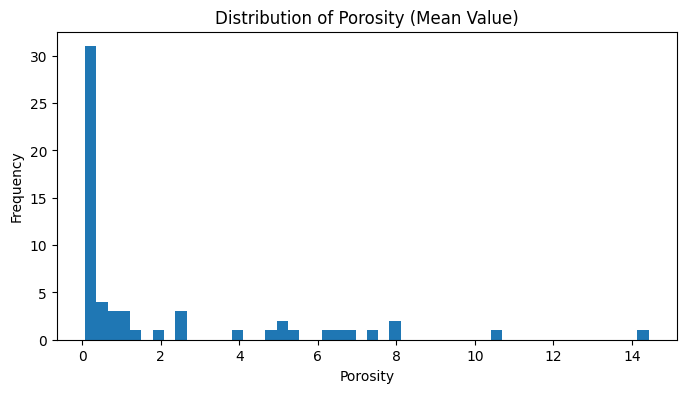

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50)
plt.title("Distribution of Porosity (Mean Value)")
plt.xlabel("Porosity")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df_clean = df[df["Porosity (Mean Value)"] < 10]
X_clean = df_clean[X.columns]
y_clean = df_clean["Porosity (Mean Value)"]
# Retrain on cleaned data

In [ ]:
X["Power_x_Speed"] = X["Power P (W)"] * X["Speed v (mm/s)"]
X["Hatch_x_Layer"] = X["Hatch Spacing h (mm)"] * X["Layer Thickness t (mm)"]
# Retrain with new features

<ipython-input-11-8753f92af05d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Power_x_Speed"] = X["Power P (W)"] * X["Speed v (mm/s)"]


In [ ]:
from scipy.stats import loguniform

param_dist = {
    'hidden_layer_sizes': [(20,), (20, 10), (50, 20)],  # Simpler architectures
    'alpha': loguniform(1e-4, 1e-2),  # Tighter regularization range
    'learning_rate_init': loguniform(1e-4, 1e-2)  # Control learning rate
}

search = RandomizedSearchCV(
    MLPRegressor(max_iter=2000, early_stopping=True, random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='r2'
)
search.fit(X_train_scaled, y_train)
print(f"Best R²: {search.best_score_:.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Best R²: -0.224


Test R²: -0.217
Best params: {'activation': 'tanh', 'alpha': np.float64(0.003114630382925443), 'early_stopping': True, 'hidden_layer_sizes': (50, 20), 'learning_rate_init': np.float64(0.000959910195327829)}
CV R²: 0.089 (±0.507)


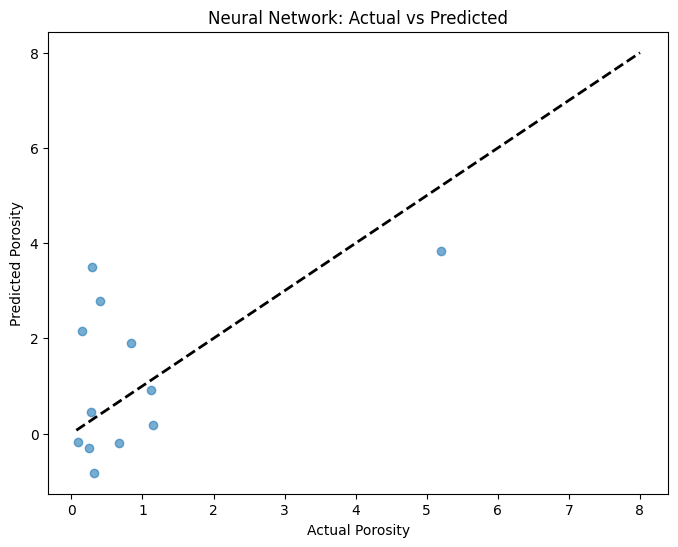

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from scipy.stats import loguniform

# Load and prepare data
df = pd.read_csv("processed_data_porsity_remake.csv")
X = df[["Power P (W)", "Speed v (mm/s)", "Layer Thickness t (mm)", "Hatch Spacing h (mm)"]]
y = df["Porosity (Mean Value)"]

# Remove extreme outliers (critical for neural networks)
df = df[df["Porosity (Mean Value)"] < 10]  # Adjust threshold based on your data distribution
X = df[["Power P (W)", "Speed v (mm/s)", "Layer Thickness t (mm)", "Hatch Spacing h (mm)"]]
y = df["Porosity (Mean Value)"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature engineering
X_train["Power_x_Speed"] = X_train["Power P (W)"] * X_train["Speed v (mm/s)"]
X_test["Power_x_Speed"] = X_test["Power P (W)"] * X_test["Speed v (mm/s)"]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized Neural Network
param_dist = {
    'hidden_layer_sizes': [(50, 20), (100, 50), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': loguniform(1e-5, 1e-2),
    'learning_rate_init': loguniform(1e-4, 1e-2),
    'early_stopping': [True]
}

nn = MLPRegressor(max_iter=2000, random_state=42)
search = RandomizedSearchCV(nn, param_dist, n_iter=30, cv=5, scoring='r2', n_jobs=-1)
search.fit(X_train_scaled, y_train)

# Best model evaluation
best_nn = search.best_estimator_
y_pred = best_nn.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test, y_pred):.3f}")
print(f"Best params: {search.best_params_}")

# Cross-validation
scores = cross_val_score(best_nn, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"CV R²: {np.mean(scores):.3f} (±{np.std(scores):.3f})")

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Porosity')
plt.ylabel('Predicted Porosity')
plt.title('Neural Network: Actual vs Predicted')
plt.show()

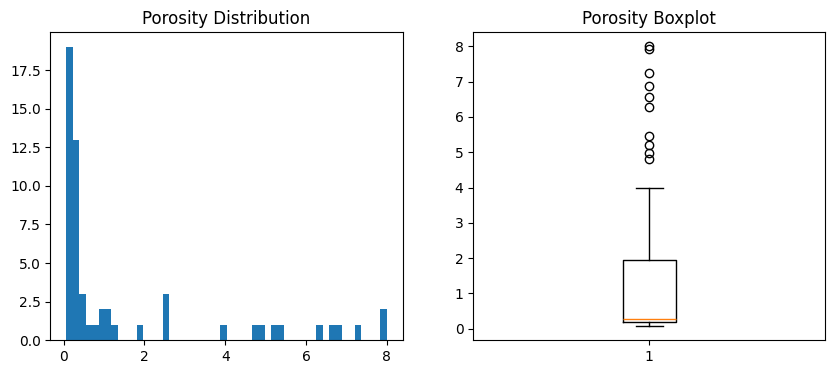

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=50)
plt.title("Porosity Distribution")
plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.title("Porosity Boxplot")
plt.show()

In [ ]:
df = df[df["Porosity (Mean Value)"] < 5]  # Tune threshold

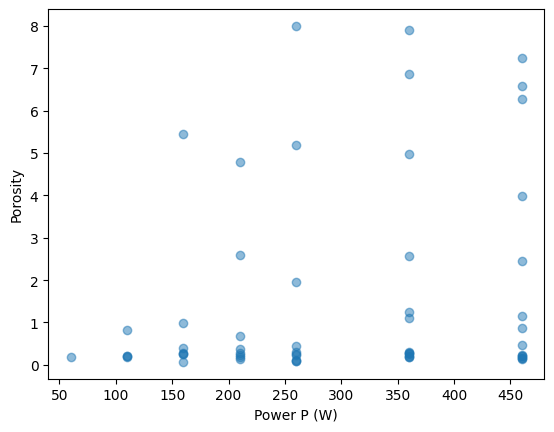

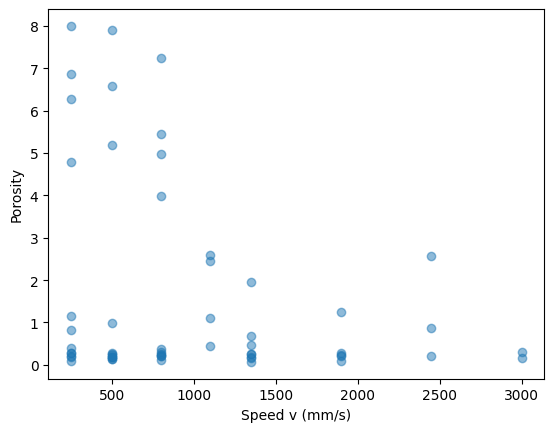

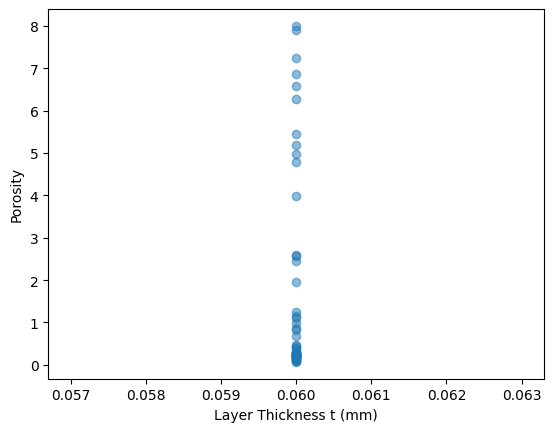

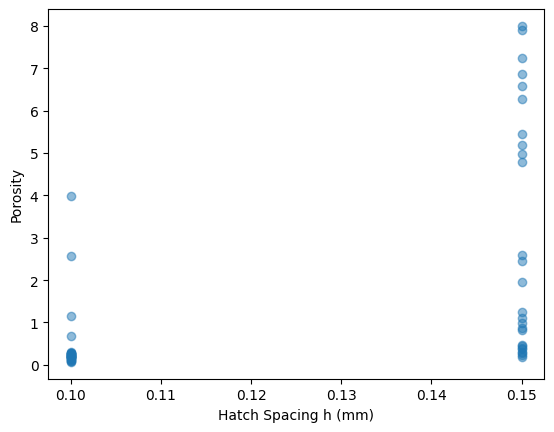

In [ ]:
for col in X.columns:
    plt.scatter(X[col], y, alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Porosity")
    plt.show()

In [ ]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(20,),  # Single hidden layer
    activation='relu',
    solver='adam',
    alpha=0.01,  # Stronger regularization
    max_iter=1000,
    random_state=42
)
nn.fit(X_train_scaled, y_train)
y_pred = nn.predict(X_test_scaled)
print(f"R²: {r2_score(y_test, y_pred):.3f}")

R²: -0.896


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
X["Power/Speed"] = X["Power P (W)"] / X["Speed v (mm/s)"]  # Energy density proxy
X["Hatch/Layer"] = X["Hatch Spacing h (mm)"] / X["Layer Thickness t (mm)"]

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
# Retrain with X_poly instead of X

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perce

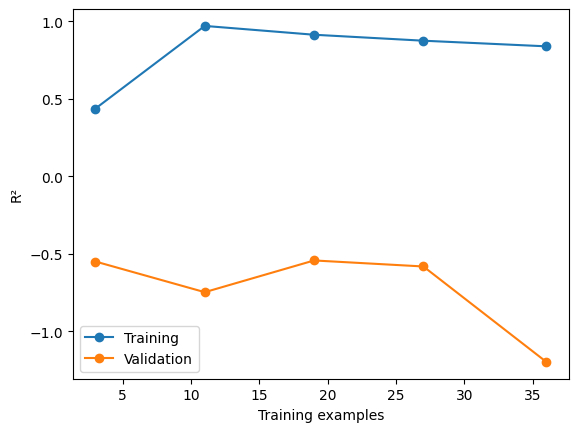

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    nn, X_train_scaled, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label="Validation")
plt.xlabel("Training examples")
plt.ylabel("R²")
plt.legend()
plt.show()

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=200, max_depth=3)
xgb.fit(X_train_scaled, y_train)
print(f"XGBoost R²: {r2_score(y_test, xgb.predict(X_test_scaled)):.3f}")

XGBoost R²: -3.266


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(20, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train_scaled, y_train,
                   validation_split=0.2,
                   epochs=200, verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(50, 20), (100, 50), (50, 50, 20), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [1000, 2000]
}

# Grid search with cross-validation
grid = GridSearchCV(MLPRegressor(random_state=42), param_grid,
                   cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

# Best model
best_nn = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_nn.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Improved R² = {r2:.3f}")
print(f"Improved RMSE = {rmse:.3f}")

Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50, 20), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'lbfgs'}
Improved R² = -0.257
Improved RMSE = 1.505


In [ ]:
# Create interaction terms and polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Scale the new features
scaler_poly = StandardScaler()
X_poly_train_scaled = scaler_poly.fit_transform(X_poly_train)
X_poly_test_scaled = scaler_poly.transform(X_poly_test)

# Train model on enhanced features
nn_poly = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                      solver='adam', max_iter=2000, random_state=42)
nn_poly.fit(X_poly_train_scaled, y_train)

# Evaluate
y_pred_poly = nn_poly.predict(X_poly_test_scaled)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"R² with polynomial features: {r2_poly:.3f}")

R² with polynomial features: -0.165


In [ ]:
# Try different scaling methods
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# RobustScaler is less sensitive to outliers
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

nn_robust = MLPRegressor(hidden_layer_sizes=(100, 50), activation='tanh',
                        solver='adam', max_iter=2000, random_state=42)
nn_robust.fit(X_train_robust, y_train)

y_pred_robust = nn_robust.predict(X_test_robust)
r2_robust = r2_score(y_test, y_pred_robust)
print(f"R² with RobustScaler: {r2_robust:.3f}")

R² with RobustScaler: 0.262


In [ ]:
# Option 1: Log transform the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

nn_log = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                     solver='adam', max_iter=2000, random_state=42)
nn_log.fit(X_train_scaled, y_train_log)

y_pred_log = nn_log.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Convert back to original scale

r2_log = r2_score(np.expm1(y_test_log), y_pred)
print(f"R² with log-transformed target: {r2_log:.3f}")

# Option 2: Remove extreme outliers
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
filter_mask = (y >= (Q1 - 1.5 * IQR)) & (y <= (Q3 + 1.5 * IQR))
df_filtered = df[filter_mask]

# Then retrain model on filtered data

R² with log-transformed target: -1.505


<ipython-input-27-211f8e404773>:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[filter_mask]


In [ ]:
# Try deeper/wider networks with early stopping
nn_deep = MLPRegressor(hidden_layer_sizes=(100, 50, 20),
                      activation='relu', solver='adam',
                      early_stopping=True, validation_fraction=0.2,
                      max_iter=2000, random_state=42)
nn_deep.fit(X_train_scaled, y_train)

y_pred_deep = nn_deep.predict(X_test_scaled)
r2_deep = r2_score(y_test, y_pred_deep)
print(f"R² with deeper network: {r2_deep:.3f}")

R² with deeper network: -0.854


In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Create ensemble of different models
ensemble = VotingRegressor([
    ('nn1', MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu')),
    ('nn2', MLPRegressor(hidden_layer_sizes=(50, 20), activation='tanh')),
    ('svr', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])

ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = ensemble.predict(X_test_scaled)
r2_ensemble = r2_score(y_test, y_pred_ensemble)
print(f"R² with ensemble: {r2_ensemble:.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


R² with ensemble: -0.565


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
scores = cross_val_score(nn, X_train_scaled, y_train,
                        cv=5, scoring='r2')
print(f"Cross-validated R² scores: {scores}")
print(f"Mean CV R²: {np.mean(scores):.3f} (±{np.std(scores):.3f})")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-validated R² scores: [ 0.77186964  0.71141542  0.59346641 -6.07896062 -1.98880301]
Mean CV R²: -1.198 (±2.653)


count    57.000000
mean      1.610557
std       2.367803
min       0.069400
25%       0.204480
50%       0.282030
75%       1.960034
max       8.000492
Name: Porosity (Mean Value), dtype: float64


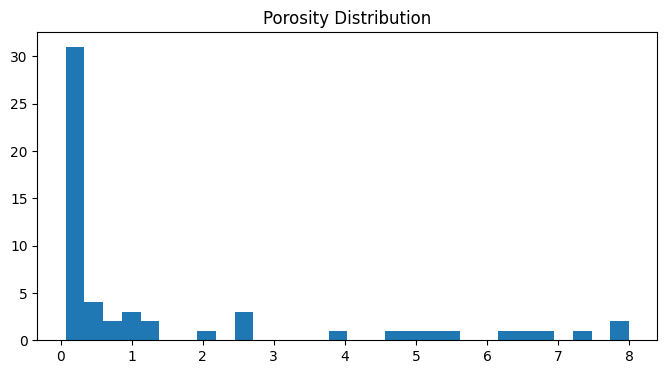

Number of outliers: 10
52    4.793489
38    4.974716
49    5.196576
33    5.456135
41    6.280564
51    6.574309
37    6.867633
42    7.254501
50    7.912903
34    8.000492
Name: Porosity (Mean Value), dtype: float64


In [ ]:
# Check your target variable distribution
print(y.describe())
plt.figure(figsize=(8,4))
plt.hist(y, bins=30)
plt.title('Porosity Distribution')
plt.show()

# Check for extreme outliers
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
outliers = y[(y < (Q1 - 1.5*IQR)) | (y > (Q3 + 1.5*IQR))]
print(f"Number of outliers: {len(outliers)}")
print(outliers.sort_values())

In [ ]:
# Start with a simpler model
simple_nn = MLPRegressor(hidden_layer_sizes=(10,),
                        activation='relu',
                        solver='adam',
                        max_iter=1000,
                        random_state=42)
simple_nn.fit(X_train_scaled, y_train)
y_pred_simple = simple_nn.predict(X_test_scaled)
print(f"Simple model R²: {r2_score(y_test, y_pred_simple):.3f}")

Simple model R²: -0.727


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Log transform the target (since you have extreme values)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

nn_log = MLPRegressor(hidden_layer_sizes=(20,10),
                     activation='relu',
                     solver='adam',
                     max_iter=2000,
                     random_state=42)
nn_log.fit(X_train_scaled, y_train_log)

# Convert predictions back
y_pred_log = np.expm1(nn_log.predict(X_test_scaled))
print(f"Log-transformed R²: {r2_score(y_test, y_pred_log):.3f}")

Log-transformed R²: 0.274


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Try linear model first
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
print(f"Ridge R²: {r2_score(y_test, ridge.predict(X_test_scaled)):.3f}")

# Try random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print(f"RF R²: {r2_score(y_test, rf.predict(X_test_scaled)):.3f}")

Ridge R²: -1.005
RF R²: -0.908


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

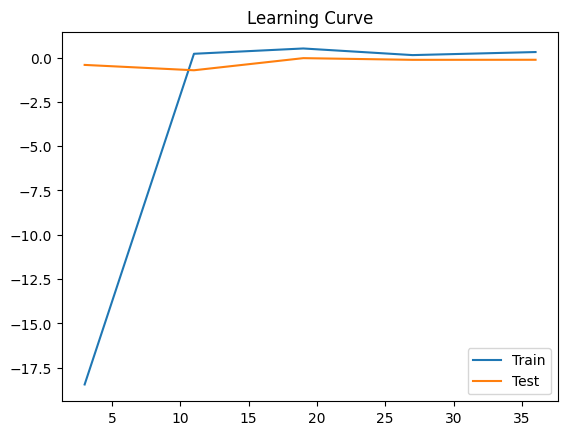

In [ ]:
# Learning curve visualization
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    MLPRegressor(hidden_layer_sizes=(10,)),
    X_train_scaled, y_train,
    cv=5, scoring='r2')

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
plt.legend()
plt.title('Learning Curve')
plt.show()

###cg


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)


In [ ]:
nn = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                  solver='adam', max_iter=2000, random_state=42, early_stopping=True)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(50, 20), (100, 50), (64, 32, 16)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid = GridSearchCV(MLPRegressor(max_iter=2000, early_stopping=True, random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)


Best parameters: {'alpha': 0.001, 'hidden_layer_sizes': (50, 20), 'learning_rate_init': 0.01}


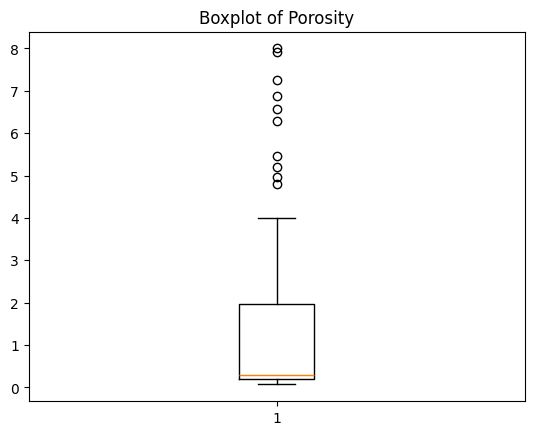

In [ ]:
plt.boxplot(y)
plt.title("Boxplot of Porosity")
plt.show()


In [ ]:
# Retrain model with best parameters
best_nn = MLPRegressor(hidden_layer_sizes=(50, 20),
                       alpha=0.001,
                       learning_rate_init=0.01,
                       max_iter=2000,
                       early_stopping=True,
                       random_state=42)

best_nn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_best = best_nn.predict(X_test_scaled)

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Tuned Neural Network Performance:")
print(f"R² = {r2_best:.3f}")
print(f"RMSE = {rmse_best:.3f}")


Tuned Neural Network Performance:
R² = -1.309
RMSE = 2.040


Tuned Neural Network Performance:
R² = 0.003
RMSE = 3.418


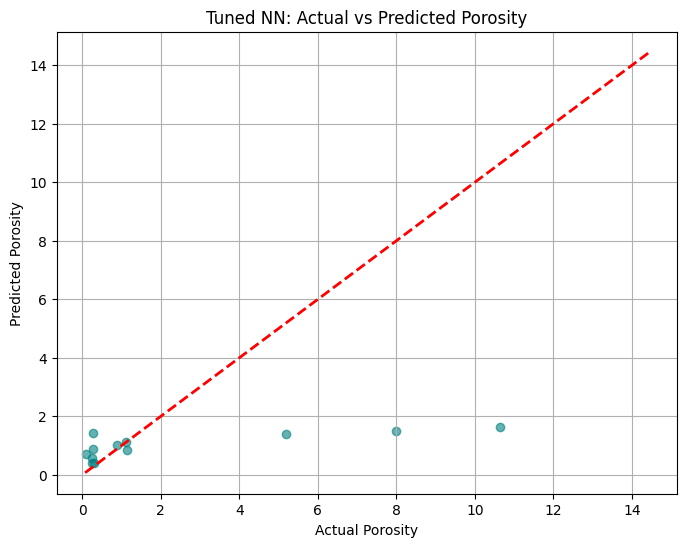

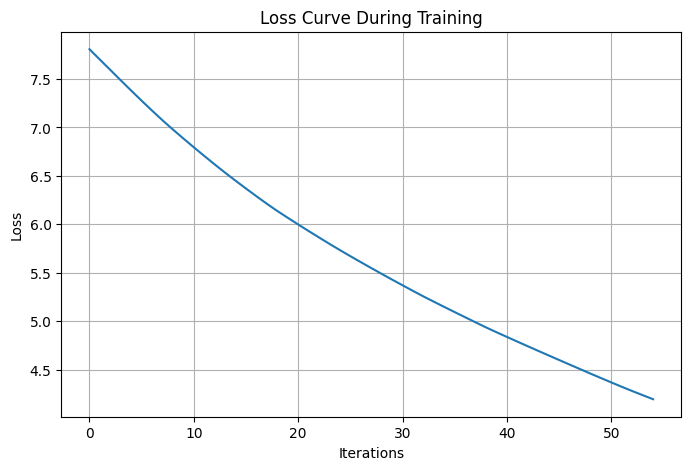

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("processed_data_porsity_remake.csv")
X = df[["Power P (W)", "Speed v (mm/s)", "Layer Thickness t (mm)", "Hatch Spacing h (mm)"]]
y = df["Porosity (Mean Value)"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train tuned neural network
best_nn = MLPRegressor(
    hidden_layer_sizes=(50, 20),
    alpha=0.001,
    learning_rate_init=0.001,  # safer learning rate
    max_iter=3000,
    early_stopping=True,
    random_state=42
)
best_nn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_best = best_nn.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Tuned Neural Network Performance:")
print(f"R² = {r2_best:.3f}")
print(f"RMSE = {rmse_best:.3f}")

# Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Porosity')
plt.ylabel('Predicted Porosity')
plt.title('Tuned NN: Actual vs Predicted Porosity')
plt.grid(True)
plt.show()

# Plot: Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(best_nn.loss_curve_)
plt.title('Loss Curve During Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (50, 50, 20)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'solver': ['adam', 'lbfgs'],
}

grid_search = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R²:", grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50, 20), 'learning_rate_init': 0.001, 'solver': 'lbfgs'}
Best cross-validated R²: -0.06686668302709378


In [ ]:
MLPRegressor(
    hidden_layer_sizes=(50, 20),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)


MLPRegressor(hidden_layer_sizes=(50, 20), learning_rate_init=0.01,
             max_iter=1000, random_state=42)

In [ ]:
best_nn = MLPRegressor(
    hidden_layer_sizes=(50, 20),
    activation='relu',
    solver='adam',
    learning_rate_init=0.005,  # try 0.005 or 0.01
    alpha=0.0001,              # regularization strength
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

best_nn.fit(X_train_scaled, y_train)
y_pred = best_nn.predict(X_test_scaled)

print("Refined Neural Network Performance:")
print("R² = {:.3f}".format(r2_score(y_test, y_pred)))
print("RMSE = {:.3f}".format(np.sqrt(mean_squared_error(y_test, y_pred))))


Refined Neural Network Performance:
R² = 0.040
RMSE = 3.354
